# Water-Sensor Data Cleaning Pipeline

This notebook prepares the water-sensor measurements used by the clustering pipeline.

The cleaning strategy is intentionally conservative:

- known database/sensor error codes are converted to `NaN`,
- broad technical limits remove impossible measurements,
- persistent oxygen-sensor failure is detected separately from genuine low oxygen,
- short conductivity collapses and isolated turbidity spikes are removed only when they match specific temporal patterns,
- rows are removed only when `df_model` is built.

Two sensors (`977`, `981`) have known oxygen drift, so oxygen is excluded from their modelling features rather than used for row filtering.


## 1. Imports and data input

In [1]:
import numpy as np
import pandas as pd

DATA_PATH = r"C:\Users\User\Desktop\water\data\water_stats.csv"
OUTPUT_PATH = "data/water_model_ready2.csv"

df = pd.read_csv(DATA_PATH)

print(f"Loaded dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded dataframe: 34,146 rows × 19 columns


## 2. Configuration

All thresholds used by the cleaning rules are kept in one place so that the pipeline can be reviewed or adjusted without searching through the notebook.

The hard limits below are **technical screening limits**, not water-quality standards.


In [2]:
SENSOR_COL = "sensor_id"
TIME_COL = "date_insert"

CONDUCTIVITY_COL = "conductivity_of_solution_ mS_cm"
ORP_COL = "oxidation_reduction_potential_ mV"
OXYGEN_COL = "oxygen_saturation_%"
TURBIDITY_COL = "turbidity_NTU"

MODEL_FEATURES = [
    CONDUCTIVITY_COL,
    ORP_COL,
    OXYGEN_COL,
    TURBIDITY_COL,
]

# Oxygen is not used for these sensors because of known drift.
OXYGEN_EXCLUDED_SENSORS = [977, 981]

REGIONS = {
    976: "Ακταίο",
    977: "Ψαθόπυργος",
    978: "Αραχωβίτικα",
    979: "Άγιος Βασίλης",
    980: "Ρίο",
    981: "Καστελλόκαμπος",
    982: "Δάφνες",
    983: "Πλάζ",
    984: "Ροιτικά",
}

SENTINEL_VALUES = [
    9998.01,
    9999.01,
    9999.0,
    -999.0,
    9998.04,
    9991.04,
    9997.03,
    9998.06,
]

HARD_LIMITS = {
    CONDUCTIVITY_COL: (0.0, 100_000.0),
    ORP_COL: (-1_000.0, 1_000.0),
    OXYGEN_COL: (0.0, 200.0),
    TURBIDITY_COL: (0.1, 1_000.0),
}

# ------------------------------------------------------------------
# Persistent oxygen-failure detection
# ------------------------------------------------------------------

OXYGEN_BASELINE_DAYS = 30

OXYGEN_LOW_MEDIAN_RATIO = 0.35
OXYGEN_VERY_LOW_Q10_RATIO = 0.20
OXYGEN_INSTABILITY_MULTIPLIER = 3.0
OXYGEN_MIN_BASELINE_IQR = 5.0

OXYGEN_ROLLING_DAYS = 7
OXYGEN_ROLLING_MIN_PERIODS = 5
OXYGEN_SUSPICIOUS_DAYS_REQUIRED = 4

# Manual review showed that sensor 980 entered its failure regime on
# 2025-11-14. Sentinel-heavy days delayed the automatic persistence
# detector until December, so this date intentionally overrides it.
MANUAL_OXYGEN_FAILURE_DATES = {
    980: pd.Timestamp("2025-11-14"),
}

# ------------------------------------------------------------------
# Conductivity: short drop-and-recovery rule
# ------------------------------------------------------------------

CONDUCTIVITY_DROP_RATIO = 0.35
CONDUCTIVITY_RECOVERY_RATIO = 0.75
MIN_CONDUCTIVITY_BASELINE = 20_000
MIN_CONDUCTIVITY_DROP = 10_000
MAX_TRANSIENT_READINGS = 3
CONDUCTIVITY_MAX_SEQUENCE_GAP = pd.Timedelta("2h")
MAX_RECOVERY_GAP = pd.Timedelta("4h")

# Conductivity: additional short local-collapse rule.
CONDUCTIVITY_LOCAL_RATIO = 0.45
MIN_LOCAL_CONDUCTIVITY_DROP = 10_000
MAX_LOCAL_COLLAPSE_READINGS = 4

# Conductivity: targeted cleanup for sensors 982 and 984.
TARGET_CONDUCTIVITY_SENSORS = [982, 984]
TARGET_CONDUCTIVITY_RATIO = 0.70
TARGET_MIN_ABSOLUTE_DROP = 8_000
TARGET_MAX_COLLAPSE_READINGS = 6
TARGET_MAX_SEQUENCE_GAP = pd.Timedelta("2h")

# Turbidity: isolated spike rule.
MIN_TURBIDITY_SPIKE = 150.0
TURBIDITY_SPIKE_RATIO = 4.0
MAX_TURBIDITY_SPIKE_READINGS = 2
TURBIDITY_MAX_SEQUENCE_GAP = pd.Timedelta("2h")

## 3. Prepare the dataframe

In [3]:
df_raw = df.copy(deep=True)
df_clean = df.copy(deep=True)

# Fail immediately if required fields cannot be parsed.
df_clean[TIME_COL] = pd.to_datetime(
    df_clean[TIME_COL],
    errors="raise",
)

for column in MODEL_FEATURES:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="raise",
    )

if "location" not in df_clean.columns:
    df_clean["location"] = df_clean[SENSOR_COL].map(REGIONS)

df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

print(f"Rows: {len(df_clean):,}")
print(f"Sensors: {df_clean[SENSOR_COL].nunique()}")

Rows: 34,146
Sensors: 9


## 4. Sentinel values and technical limits

Known error codes and technically impossible measurements are converted to `NaN`.

No rows are removed at this stage. Keeping the rows in `df_clean` preserves the timestamps and cleaning flags; the final modelling dataset is filtered later.


In [4]:
for column in MODEL_FEATURES:
    sentinel_mask = pd.Series(
        False,
        index=df_clean.index,
    )

    for sentinel in SENTINEL_VALUES:
        sentinel_mask |= np.isclose(
            df_clean[column],
            sentinel,
            rtol=0.0,
            atol=1e-6,
            equal_nan=False,
        )

    df_clean[f"{column}__sentinel_invalid"] = sentinel_mask
    df_clean.loc[sentinel_mask, column] = np.nan

for column, (lower_limit, upper_limit) in HARD_LIMITS.items():
    hard_limit_mask = (
        df_clean[column].notna()
        & (
            (df_clean[column] < lower_limit)
            | (df_clean[column] > upper_limit)
        )
    )

    df_clean[f"{column}__hard_limit_invalid"] = hard_limit_mask
    df_clean.loc[hard_limit_mask, column] = np.nan

## 5. Persistent oxygen-sensor failure

A simple hard lower bound is not sufficient for oxygen saturation: several sensors eventually enter a sustained failure regime containing near-zero values, instability, or long sequences of error measurements.

The detector therefore works at the **daily sensor level**:

1. use the first 30 days as that sensor's baseline,
2. flag days with a strong collapse or unusually low and unstable readings,
3. require persistence (`4` suspicious days within a rolling `7`-day window),
4. use the first persistent date as the automatic failure date.

Sensors `977` and `981` are not evaluated here because oxygen is already excluded from their modelling features.


In [5]:
oxygen_diag = df_raw.loc[
    ~df_raw[SENSOR_COL].isin(OXYGEN_EXCLUDED_SENSORS),
    [SENSOR_COL, TIME_COL, OXYGEN_COL],
].copy()

oxygen_diag[TIME_COL] = pd.to_datetime(
    oxygen_diag[TIME_COL],
    errors="raise",
)

oxygen_diag[OXYGEN_COL] = pd.to_numeric(
    oxygen_diag[OXYGEN_COL],
    errors="raise",
)

# Remove known error codes from the diagnostic series while preserving
# genuine low oxygen measurements.
for sentinel in SENTINEL_VALUES:
    sentinel_mask = np.isclose(
        oxygen_diag[OXYGEN_COL],
        sentinel,
        rtol=0.0,
        atol=1e-6,
        equal_nan=False,
    )
    oxygen_diag.loc[sentinel_mask, OXYGEN_COL] = np.nan

oxygen_lower, oxygen_upper = HARD_LIMITS[OXYGEN_COL]

oxygen_diag.loc[
    (oxygen_diag[OXYGEN_COL] < oxygen_lower)
    | (oxygen_diag[OXYGEN_COL] > oxygen_upper),
    OXYGEN_COL,
] = np.nan

oxygen_diag["day"] = oxygen_diag[TIME_COL].dt.floor("D")

daily_oxygen = (
    oxygen_diag
    .groupby([SENSOR_COL, "day"])[OXYGEN_COL]
    .agg(
        median="median",
        q10=lambda x: x.quantile(0.10),
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count="count",
    )
    .reset_index()
)

daily_oxygen["iqr"] = (
    daily_oxygen["q75"]
    - daily_oxygen["q25"]
)

In [6]:
baseline_rows = []

for sensor_id, sensor_df in daily_oxygen.groupby(SENSOR_COL):
    sensor_df = sensor_df.sort_values("day")

    start_date = sensor_df["day"].min()
    baseline_end = start_date + pd.Timedelta(
        days=OXYGEN_BASELINE_DAYS
    )

    baseline = sensor_df.loc[
        sensor_df["day"] < baseline_end
    ]

    baseline_rows.append({
        SENSOR_COL: sensor_id,
        "baseline_oxygen": baseline["median"].median(),
        "baseline_iqr": baseline["iqr"].median(),
        "baseline_days": len(baseline),
    })

oxygen_baseline = pd.DataFrame(baseline_rows)

daily_oxygen = daily_oxygen.merge(
    oxygen_baseline,
    on=SENSOR_COL,
    how="left",
)

daily_oxygen["low_median"] = (
    daily_oxygen["median"]
    < OXYGEN_LOW_MEDIAN_RATIO
    * daily_oxygen["baseline_oxygen"]
)

daily_oxygen["very_low_values"] = (
    daily_oxygen["q10"]
    < OXYGEN_VERY_LOW_Q10_RATIO
    * daily_oxygen["baseline_oxygen"]
)

daily_oxygen["high_instability"] = (
    daily_oxygen["iqr"]
    > OXYGEN_INSTABILITY_MULTIPLIER
    * daily_oxygen["baseline_iqr"].clip(
        lower=OXYGEN_MIN_BASELINE_IQR
    )
)

daily_oxygen["oxygen_suspicious"] = (
    daily_oxygen["low_median"]
    | (
        daily_oxygen["very_low_values"]
        & daily_oxygen["high_instability"]
    )
)

daily_oxygen = (
    daily_oxygen
    .sort_values([SENSOR_COL, "day"])
    .reset_index(drop=True)
)

daily_oxygen["suspicious_last_7"] = (
    daily_oxygen
    .groupby(SENSOR_COL)["oxygen_suspicious"]
    .transform(
        lambda x: x.rolling(
            window=OXYGEN_ROLLING_DAYS,
            min_periods=OXYGEN_ROLLING_MIN_PERIODS,
        ).sum()
    )
)

daily_oxygen["persistent_failure"] = (
    daily_oxygen["suspicious_last_7"]
    >= OXYGEN_SUSPICIOUS_DAYS_REQUIRED
)

### 5.1 Automatic dates and manual review

The automatic detector is kept as the default.

Sensor **980 (Ρίο)** is the only manual override. Visual review showed the failure regime beginning on **2025-11-14**, followed by sentinel-heavy periods. Because those sentinel days become missing values in the diagnostic series, the rolling detector does not reach its persistence threshold until December.

The override changes only the failure start date for sensor 980; the detection logic for every other sensor remains automatic.


In [7]:
automatic_failure_dates = (
    daily_oxygen.loc[
        daily_oxygen["persistent_failure"]
    ]
    .groupby(SENSOR_COL)["day"]
    .min()
    .rename("automatic_failure_date")
    .reset_index()
)

failure_dates = (
    pd.DataFrame({
        SENSOR_COL: sorted(
            daily_oxygen[SENSOR_COL].unique()
        )
    })
    .merge(
        automatic_failure_dates,
        on=SENSOR_COL,
        how="left",
    )
)

failure_dates["final_failure_date"] = (
    failure_dates["automatic_failure_date"]
)

failure_dates["failure_date_source"] = np.where(
    failure_dates["automatic_failure_date"].notna(),
    "automatic",
    "none detected",
)

for sensor_id, manual_date in MANUAL_OXYGEN_FAILURE_DATES.items():
    sensor_mask = (
        failure_dates[SENSOR_COL] == sensor_id
    )

    failure_dates.loc[
        sensor_mask,
        "final_failure_date",
    ] = manual_date

    failure_dates.loc[
        sensor_mask,
        "failure_date_source",
    ] = "manual override"

failure_dates["location"] = (
    failure_dates[SENSOR_COL].map(REGIONS)
)

display(
    failure_dates[
        [
            SENSOR_COL,
            "location",
            "automatic_failure_date",
            "final_failure_date",
            "failure_date_source",
        ]
    ]
)

,sensor_id,location,automatic_failure_date,final_failure_date,failure_date_source
0,976,Ακταίο,2025-09-05,2025-09-05,automatic
1,978,Αραχωβίτικα,NaT,NaT,none detected
2,979,Άγιος Βασίλης,2025-12-01,2025-12-01,automatic
3,980,Ρίο,2025-12-12,2025-11-14,manual override
4,982,Δάφνες,2025-12-19,2025-12-19,automatic
5,983,Πλάζ,2025-11-17,2025-11-17,automatic
6,984,Ροιτικά,2025-11-25,2025-11-25,automatic


### 5.2 Apply the oxygen failure dates

Once a sensor enters its final failure regime, its oxygen values are no longer treated as valid measurements.

Only `oxygen_saturation_%` is invalidated; the rest of the row is preserved in `df_clean`.


In [8]:
df_clean["oxygen_persistent_failure"] = False

for row in failure_dates.dropna(
    subset=["final_failure_date"]
).itertuples(index=False):

    failure_mask = (
        (df_clean[SENSOR_COL] == row.sensor_id)
        & (
            df_clean[TIME_COL]
            >= row.final_failure_date
        )
    )

    df_clean.loc[
        failure_mask,
        "oxygen_persistent_failure",
    ] = True

oxygen_values_removed_by_failure = int(
    (
        df_clean["oxygen_persistent_failure"]
        & df_clean[OXYGEN_COL].notna()
    ).sum()
)

df_clean.loc[
    df_clean["oxygen_persistent_failure"],
    OXYGEN_COL,
] = np.nan

print(
    "Oxygen values invalidated after persistent sensor failure:",
    f"{oxygen_values_removed_by_failure:,}",
)

Oxygen values invalidated after persistent sensor failure: 10,258


## 6. Conductivity cleaning

Conductivity uses two general rules:

- **transient drop-and-recovery:** short, sharp drops that recover quickly,
- **local collapse:** short sequences that are much lower than the surrounding 24-hour behaviour.

Values identified by either rule are converted to `NaN`.


In [9]:
def detect_transient_conductivity_drops(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    baseline = (
        indexed[CONDUCTIVITY_COL]
        .rolling("24h", min_periods=12)
        .median()
        .shift(1)
    )

    sensor_df["conductivity_baseline_24h"] = baseline.to_numpy()

    conductivity_drop = (
        sensor_df["conductivity_baseline_24h"]
        - sensor_df[CONDUCTIVITY_COL]
    )

    candidate_drop = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df["conductivity_baseline_24h"].notna()
        & (
            sensor_df["conductivity_baseline_24h"]
            >= MIN_CONDUCTIVITY_BASELINE
        )
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= (
                CONDUCTIVITY_DROP_RATIO
                * sensor_df["conductivity_baseline_24h"]
            )
        )
        & (conductivity_drop >= MIN_CONDUCTIVITY_DROP)
    )

    sensor_df["conductivity_drop_candidate"] = candidate_drop

    time_gap = sensor_df[TIME_COL].diff()
    previous_was_candidate = candidate_drop.shift(
        fill_value=False
    )

    new_sequence = (
        candidate_drop
        & (
            ~previous_was_candidate
            | time_gap.gt(CONDUCTIVITY_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = new_sequence.cumsum().where(candidate_drop)

    sensor_df["conductivity_drop_sequence_id"] = sequence_id
    sensor_df["conductivity_transient_glitch"] = False

    for current_sequence_id in sequence_id.dropna().unique():
        sequence_positions = np.flatnonzero(
            sequence_id.eq(current_sequence_id).to_numpy()
        )

        if len(sequence_positions) > MAX_TRANSIENT_READINGS:
            continue

        first_position = sequence_positions[0]
        last_position = sequence_positions[-1]
        previous_position = first_position - 1
        next_position = last_position + 1

        if (
            previous_position < 0
            or next_position >= len(sensor_df)
        ):
            continue

        sequence_start = sensor_df.iloc[first_position][TIME_COL]
        sequence_end = sensor_df.iloc[last_position][TIME_COL]
        previous_time = sensor_df.iloc[previous_position][TIME_COL]
        next_time = sensor_df.iloc[next_position][TIME_COL]

        if (
            sequence_start - previous_time
            > CONDUCTIVITY_MAX_SEQUENCE_GAP
        ):
            continue

        if next_time - sequence_end > MAX_RECOVERY_GAP:
            continue

        baseline_at_start = sensor_df.iloc[
            first_position
        ]["conductivity_baseline_24h"]

        previous_value = sensor_df.iloc[
            previous_position
        ][CONDUCTIVITY_COL]

        next_value = sensor_df.iloc[
            next_position
        ][CONDUCTIVITY_COL]

        if (
            pd.isna(baseline_at_start)
            or pd.isna(previous_value)
            or pd.isna(next_value)
        ):
            continue

        previous_is_normal = (
            previous_value
            >= CONDUCTIVITY_RECOVERY_RATIO * baseline_at_start
        )

        next_is_recovered = (
            next_value
            >= CONDUCTIVITY_RECOVERY_RATIO * baseline_at_start
        )

        if previous_is_normal and next_is_recovered:
            sensor_df.iloc[
                sequence_positions,
                sensor_df.columns.get_loc(
                    "conductivity_transient_glitch"
                ),
            ] = True

    return sensor_df


def detect_local_conductivity_collapses(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    local_median = (
        indexed[CONDUCTIVITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12,
        )
        .median()
    )

    sensor_df["conductivity_local_median_24h"] = (
        local_median.to_numpy()
    )

    absolute_drop = (
        sensor_df["conductivity_local_median_24h"]
        - sensor_df[CONDUCTIVITY_COL]
    )

    candidate = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df["conductivity_local_median_24h"].notna()
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= (
                CONDUCTIVITY_LOCAL_RATIO
                * sensor_df["conductivity_local_median_24h"]
            )
        )
        & (absolute_drop >= MIN_LOCAL_CONDUCTIVITY_DROP)
    )

    sensor_df["conductivity_local_collapse_candidate"] = candidate

    time_gap = sensor_df[TIME_COL].diff()
    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(CONDUCTIVITY_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = new_sequence.cumsum().where(candidate)

    sensor_df["conductivity_local_collapse_sequence_id"] = (
        sequence_id
    )

    sequence_size = (
        sensor_df
        .groupby(
            "conductivity_local_collapse_sequence_id"
        )[CONDUCTIVITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df["conductivity_local_collapse_readings"] = (
        sequence_size
    )

    sensor_df["conductivity_local_collapse"] = (
        candidate
        & (sequence_size <= MAX_LOCAL_COLLAPSE_READINGS)
    )

    return sensor_df

In [10]:
df_clean = (
    df_clean
    .sort_values([SENSOR_COL, TIME_COL])
    .reset_index(drop=True)
)

df_clean["conductivity_original"] = df_clean[CONDUCTIVITY_COL]

df_clean = pd.concat(
    [
        detect_transient_conductivity_drops(sensor_df)
        for _, sensor_df in df_clean.groupby(
            SENSOR_COL,
            sort=False,
        )
    ],
    ignore_index=True,
)

df_clean.loc[
    df_clean["conductivity_transient_glitch"],
    CONDUCTIVITY_COL,
] = np.nan

df_clean["conductivity_before_local_cleaning"] = (
    df_clean[CONDUCTIVITY_COL]
)

df_clean = pd.concat(
    [
        detect_local_conductivity_collapses(sensor_df)
        for _, sensor_df in df_clean.groupby(
            SENSOR_COL,
            sort=False,
        )
    ],
    ignore_index=True,
)

df_clean.loc[
    df_clean["conductivity_local_collapse"],
    CONDUCTIVITY_COL,
] = np.nan

### 6.1 Targeted conductivity cleanup for sensors 982 and 984

Sensors `982` and `984` showed additional conductivity behaviour that was not fully captured by the general rules. A separate conservative rule is therefore applied only to these sensors.


In [11]:
# ------------------------------------------------------------
# Targeted conductivity cleanup for sensors 982 and 984
# ------------------------------------------------------------

TARGET_CONDUCTIVITY_SENSORS = [982, 984]

TARGET_CONDUCTIVITY_RATIO = 0.70
TARGET_MIN_ABSOLUTE_DROP = 8_000

# Remove only short sequences.
TARGET_MAX_COLLAPSE_READINGS = 6
TARGET_MAX_SEQUENCE_GAP = pd.Timedelta("2h")


def detect_targeted_conductivity_collapses(sensor_df):
    sensor_df = (
        sensor_df
        .sort_values(TIME_COL)
        .copy()
    )

    sensor_id = sensor_df[SENSOR_COL].iloc[0]

    sensor_df[
        "targeted_conductivity_local_median"
    ] = np.nan

    sensor_df[
        "targeted_conductivity_candidate"
    ] = False

    sensor_df[
        "targeted_conductivity_sequence_id"
    ] = np.nan

    sensor_df[
        "targeted_conductivity_sequence_size"
    ] = np.nan

    sensor_df[
        "targeted_conductivity_collapse"
    ] = False

    if sensor_id not in TARGET_CONDUCTIVITY_SENSORS:
        return sensor_df

    indexed = sensor_df.set_index(TIME_COL)

    local_median = (
        indexed[CONDUCTIVITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12
        )
        .median()
    )

    sensor_df[
        "targeted_conductivity_local_median"
    ] = local_median.to_numpy()

    absolute_drop = (
        sensor_df[
            "targeted_conductivity_local_median"
        ]
        - sensor_df[CONDUCTIVITY_COL]
    )

    candidate = (
        sensor_df[CONDUCTIVITY_COL].notna()
        & sensor_df[
            "targeted_conductivity_local_median"
        ].notna()
        & (
            sensor_df[CONDUCTIVITY_COL]
            <= TARGET_CONDUCTIVITY_RATIO
            * sensor_df[
                "targeted_conductivity_local_median"
            ]
        )
        & (
            absolute_drop
            >= TARGET_MIN_ABSOLUTE_DROP
        )
    )

    sensor_df[
        "targeted_conductivity_candidate"
    ] = candidate

    time_gap = sensor_df[TIME_COL].diff()

    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(TARGET_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = (
        new_sequence
        .cumsum()
        .where(candidate)
    )

    sensor_df[
        "targeted_conductivity_sequence_id"
    ] = sequence_id

    sequence_size = (
        sensor_df
        .groupby(
            "targeted_conductivity_sequence_id"
        )[CONDUCTIVITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df[
        "targeted_conductivity_sequence_size"
    ] = sequence_size

    sensor_df[
        "targeted_conductivity_collapse"
    ] = (
        candidate
        & (
            sequence_size
            <= TARGET_MAX_COLLAPSE_READINGS
        )
    )

    if sensor_id == 984:
        sensor_df[
            "targeted_conductivity_collapse"
        ] |= (
            sensor_df[CONDUCTIVITY_COL].notna()
            & (sensor_df[CONDUCTIVITY_COL] < 10_000)
        )

    return sensor_df

if "conductivity_before_targeted_cleaning" not in df_clean.columns:
    df_clean["conductivity_before_targeted_cleaning"] = (
        df_clean[CONDUCTIVITY_COL]
    )

df_clean = pd.concat(
    [
        detect_targeted_conductivity_collapses(sensor_df)
        for _, sensor_df in (
            df_clean
            .sort_values([SENSOR_COL, TIME_COL])
            .groupby(SENSOR_COL, sort=False)
        )
    ],
    ignore_index=True,
)

df_clean.loc[
    df_clean["targeted_conductivity_collapse"],
    CONDUCTIVITY_COL,
] = np.nan

print(
    "Targeted conductivity collapses:",
    int(df_clean["targeted_conductivity_collapse"].sum()),
)

Targeted conductivity collapses: 381


## 7. Turbidity spike cleaning

Only **short isolated spikes** are removed. Sustained high turbidity is retained because it may represent a genuine change in water conditions rather than sensor error.


In [12]:
def detect_isolated_turbidity_spikes(
    sensor_df: pd.DataFrame,
) -> pd.DataFrame:
    sensor_df = sensor_df.sort_values(TIME_COL).copy()
    indexed = sensor_df.set_index(TIME_COL)

    local_median = (
        indexed[TURBIDITY_COL]
        .rolling(
            "24h",
            center=True,
            min_periods=12,
        )
        .median()
    )

    sensor_df["turbidity_local_median_24h"] = (
        local_median.to_numpy()
    )

    absolute_increase = (
        sensor_df[TURBIDITY_COL]
        - sensor_df["turbidity_local_median_24h"]
    )

    ratio_reference = (
        sensor_df["turbidity_local_median_24h"]
        .clip(lower=10)
    )

    candidate = (
        sensor_df[TURBIDITY_COL].notna()
        & sensor_df["turbidity_local_median_24h"].notna()
        & (absolute_increase >= MIN_TURBIDITY_SPIKE)
        & (
            sensor_df[TURBIDITY_COL]
            >= TURBIDITY_SPIKE_RATIO * ratio_reference
        )
    )

    sensor_df["turbidity_spike_candidate"] = candidate

    time_gap = sensor_df[TIME_COL].diff()
    previous_was_candidate = candidate.shift(
        fill_value=False
    )

    new_sequence = (
        candidate
        & (
            ~previous_was_candidate
            | time_gap.gt(TURBIDITY_MAX_SEQUENCE_GAP)
        )
    )

    sequence_id = new_sequence.cumsum().where(candidate)

    sensor_df["turbidity_spike_sequence_id"] = sequence_id

    sequence_size = (
        sensor_df
        .groupby("turbidity_spike_sequence_id")[TURBIDITY_COL]
        .transform("size")
        .where(candidate)
    )

    sensor_df["turbidity_spike_readings"] = sequence_size

    sensor_df["isolated_turbidity_spike"] = (
        candidate
        & (sequence_size <= MAX_TURBIDITY_SPIKE_READINGS)
    )

    return sensor_df


df_clean["turbidity_before_spike_cleaning"] = (
    df_clean[TURBIDITY_COL]
)

df_clean = pd.concat(
    [
        detect_isolated_turbidity_spikes(sensor_df)
        for _, sensor_df in (
            df_clean
            .sort_values([SENSOR_COL, TIME_COL])
            .groupby(SENSOR_COL, sort=False)
        )
    ],
    ignore_index=True,
)

df_clean.loc[
    df_clean["isolated_turbidity_spike"],
    TURBIDITY_COL,
] = np.nan

print(
    "Isolated turbidity spikes:",
    int(df_clean["isolated_turbidity_spike"].sum()),
)

Isolated turbidity spikes: 183


## 8. Build the clustering dataset

`df_clean` keeps the full cleaned history and diagnostic flags.

`df_model` contains only rows with all features required by the clustering model:

- sensors other than `977` and `981` require all four features,
- sensors `977` and `981` require conductivity, ORP and turbidity only because oxygen is excluded for those sensors.


In [13]:
features_without_oxygen = [
    CONDUCTIVITY_COL,
    ORP_COL,
    TURBIDITY_COL,
]

df_model = pd.concat(
    [
        df_clean.loc[
            ~df_clean[SENSOR_COL].isin(
                OXYGEN_EXCLUDED_SENSORS
            )
        ].dropna(
            subset=MODEL_FEATURES
        ),

        df_clean.loc[
            df_clean[SENSOR_COL].isin(
                OXYGEN_EXCLUDED_SENSORS
            )
        ].dropna(
            subset=features_without_oxygen
        ),
    ],
    axis=0,
).sort_values(
    [SENSOR_COL, TIME_COL]
).reset_index(drop=True)

print(f"Original rows: {len(df_raw):,}")
print(f"Final modelling rows: {len(df_model):,}")
print(
    "Overall retention:",
    f"{100 * len(df_model) / len(df_raw):.1f}%"
)

Original rows: 34,146
Final modelling rows: 17,820
Overall retention: 52.2%


## 9. Cleaning summary

In [14]:
cleaning_summary = pd.Series({
    "Sentinel values": sum(
        int(
            df_clean[
                f"{column}__sentinel_invalid"
            ].sum()
        )
        for column in MODEL_FEATURES
    ),
    "Hard-limit violations": sum(
        int(
            df_clean[
                f"{column}__hard_limit_invalid"
            ].sum()
        )
        for column in MODEL_FEATURES
    ),
    "Oxygen values removed after persistent failure":
        oxygen_values_removed_by_failure,
    "Transient conductivity glitches": int(
        df_clean["conductivity_transient_glitch"].sum()
    ),
    "Additional conductivity collapses": int(
        df_clean["conductivity_local_collapse"].sum()
    ),
    "Targeted conductivity collapses": int(
        df_clean["targeted_conductivity_collapse"].sum()
    ),
    "Isolated turbidity spikes": int(
        df_clean["isolated_turbidity_spike"].sum()
    ),
}).astype(int)

retention_by_sensor = pd.DataFrame({
    "raw_rows": df_raw.groupby(SENSOR_COL).size(),
    "model_rows": df_model.groupby(SENSOR_COL).size(),
})

retention_by_sensor["retention_%"] = (
    100
    * retention_by_sensor["model_rows"]
    / retention_by_sensor["raw_rows"]
)

display(
    cleaning_summary.rename("count").to_frame()
)

display(
    retention_by_sensor.round(2)
)

,count
Sentinel values,1281
Hard-limit violations,4639
Oxygen values removed after persistent failure,10258
Transient conductivity glitches,64
Additional conductivity collapses,75
Targeted conductivity collapses,381
Isolated turbidity spikes,183


,raw_rows,model_rows,retention_%
sensor_id,,,
976,2607,1243,47.68
977,4084,1848,45.25
978,2908,1584,54.47
979,6073,2602,42.85
980,2915,2124,72.86
981,1757,986,56.12
982,3809,2660,69.83
983,6366,2285,35.89
984,3627,2488,68.60


## 10. Optional oxygen validation plot

This cell is only a visual check of the post-cleaning oxygen history. The plotting function is imported from `funcs.py`; no plotting helper is redefined in this notebook.


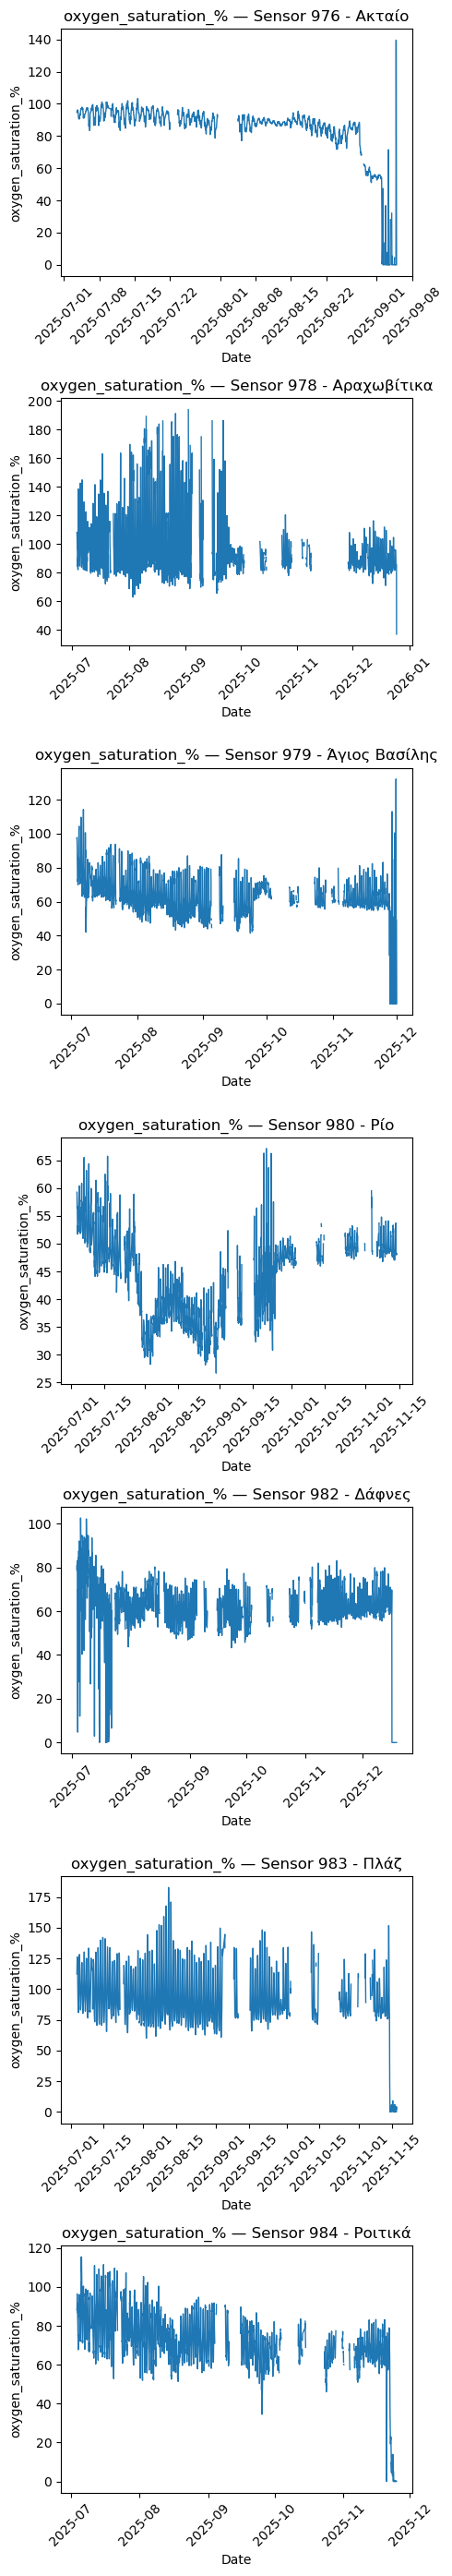

In [15]:
from funcs import plot_sensors

oxygen_validation_sensors = [
    sensor_id
    for sensor_id in sorted(df_clean[SENSOR_COL].unique())
    if sensor_id not in OXYGEN_EXCLUDED_SENSORS
]

plot_sensors(
    oxygen_validation_sensors,
    [OXYGEN_COL],
    df=df_clean,
)

## 11. Save the modelling dataset

In [16]:
df_model.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved: {OUTPUT_PATH}")

Saved: data/water_model_ready2.csv
